# Dataset Creation

In this notebook, we will create the chromatin dataset to deconvolve. This will involve multiple steps. We have many of these pieces already written in other notebooks. So this is a notebook to consolidate and bring a clear workflow to the dataset.


*Steps:*
1. Define gene set
2. Copy number normalization, as defined by Yulong Li
3. +1 Nucleosome alignment
4. Partition lengths by nucleosome, mid-size, small fragment length
5. Partition genomic position by half-nucleosome length.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# For now we will define our gene set from a previous run
# This will give us chromosome, TSS, strand information

genes = pd.read_csv('data/reference_data/geneset_nondub_w_prom_genebodies.csv')
genes.head(2)


,orf_name,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
0,YAL068C,PAU8,1,gene,1807,2169,-,Verified,362,2169,NaN,NaN,2169.0,2469.0,1669.0,2169.0
1,YAL067W-A,YAL067W-A,1,gene,2480,2707,+,Uncharacterized,227,2480,NaN,NaN,2180.0,2480.0,2480.0,2980.0


In [5]:
# Copy number normalization

# To correct for replication-dependent 

""" 

via Yulong Li, 2021

DNA copy number variation throughout the cell cycle for a given chromosomal location, 

the RPKM of all MNase-seq reads for a 1001 bp window centered at the given position
was calculated for each time point, 

the ratio of this RPKM to the RPKM of the
α-factor time point (G1) 

was considered to be the copy number. 

For each time point, 
the nucleosome score for any chromosomal location was normalized by its copy number.
"""


# In other words, the number reads was normalized by the 0 timepoint. Because at 0 time,
# cell should be in G1. 

# How does this differ than normalizing by the fragment length of the lowest
# sampled timepoint...

# Copy number seems to be important to normalize under. To ensure the number of reads match
# single copy of DNA.

# Separately, may we can then normalize by length? Or should we skip that...

# -----------------

# This may be a question to set aside


# -------------------


In [7]:
# Let's do +1 Nucleosome alignment

from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

In [124]:
chromatin_gridder.set_gene('CLB2')
plus_one = chromatin_gridder.find_max_plusOne_pos()
print(f"Computed the plus one location as: {plus_one}")
chromatin_gridder.create_bins_per_all_sample()

The histogram shape around the TSS is: (3, 9)


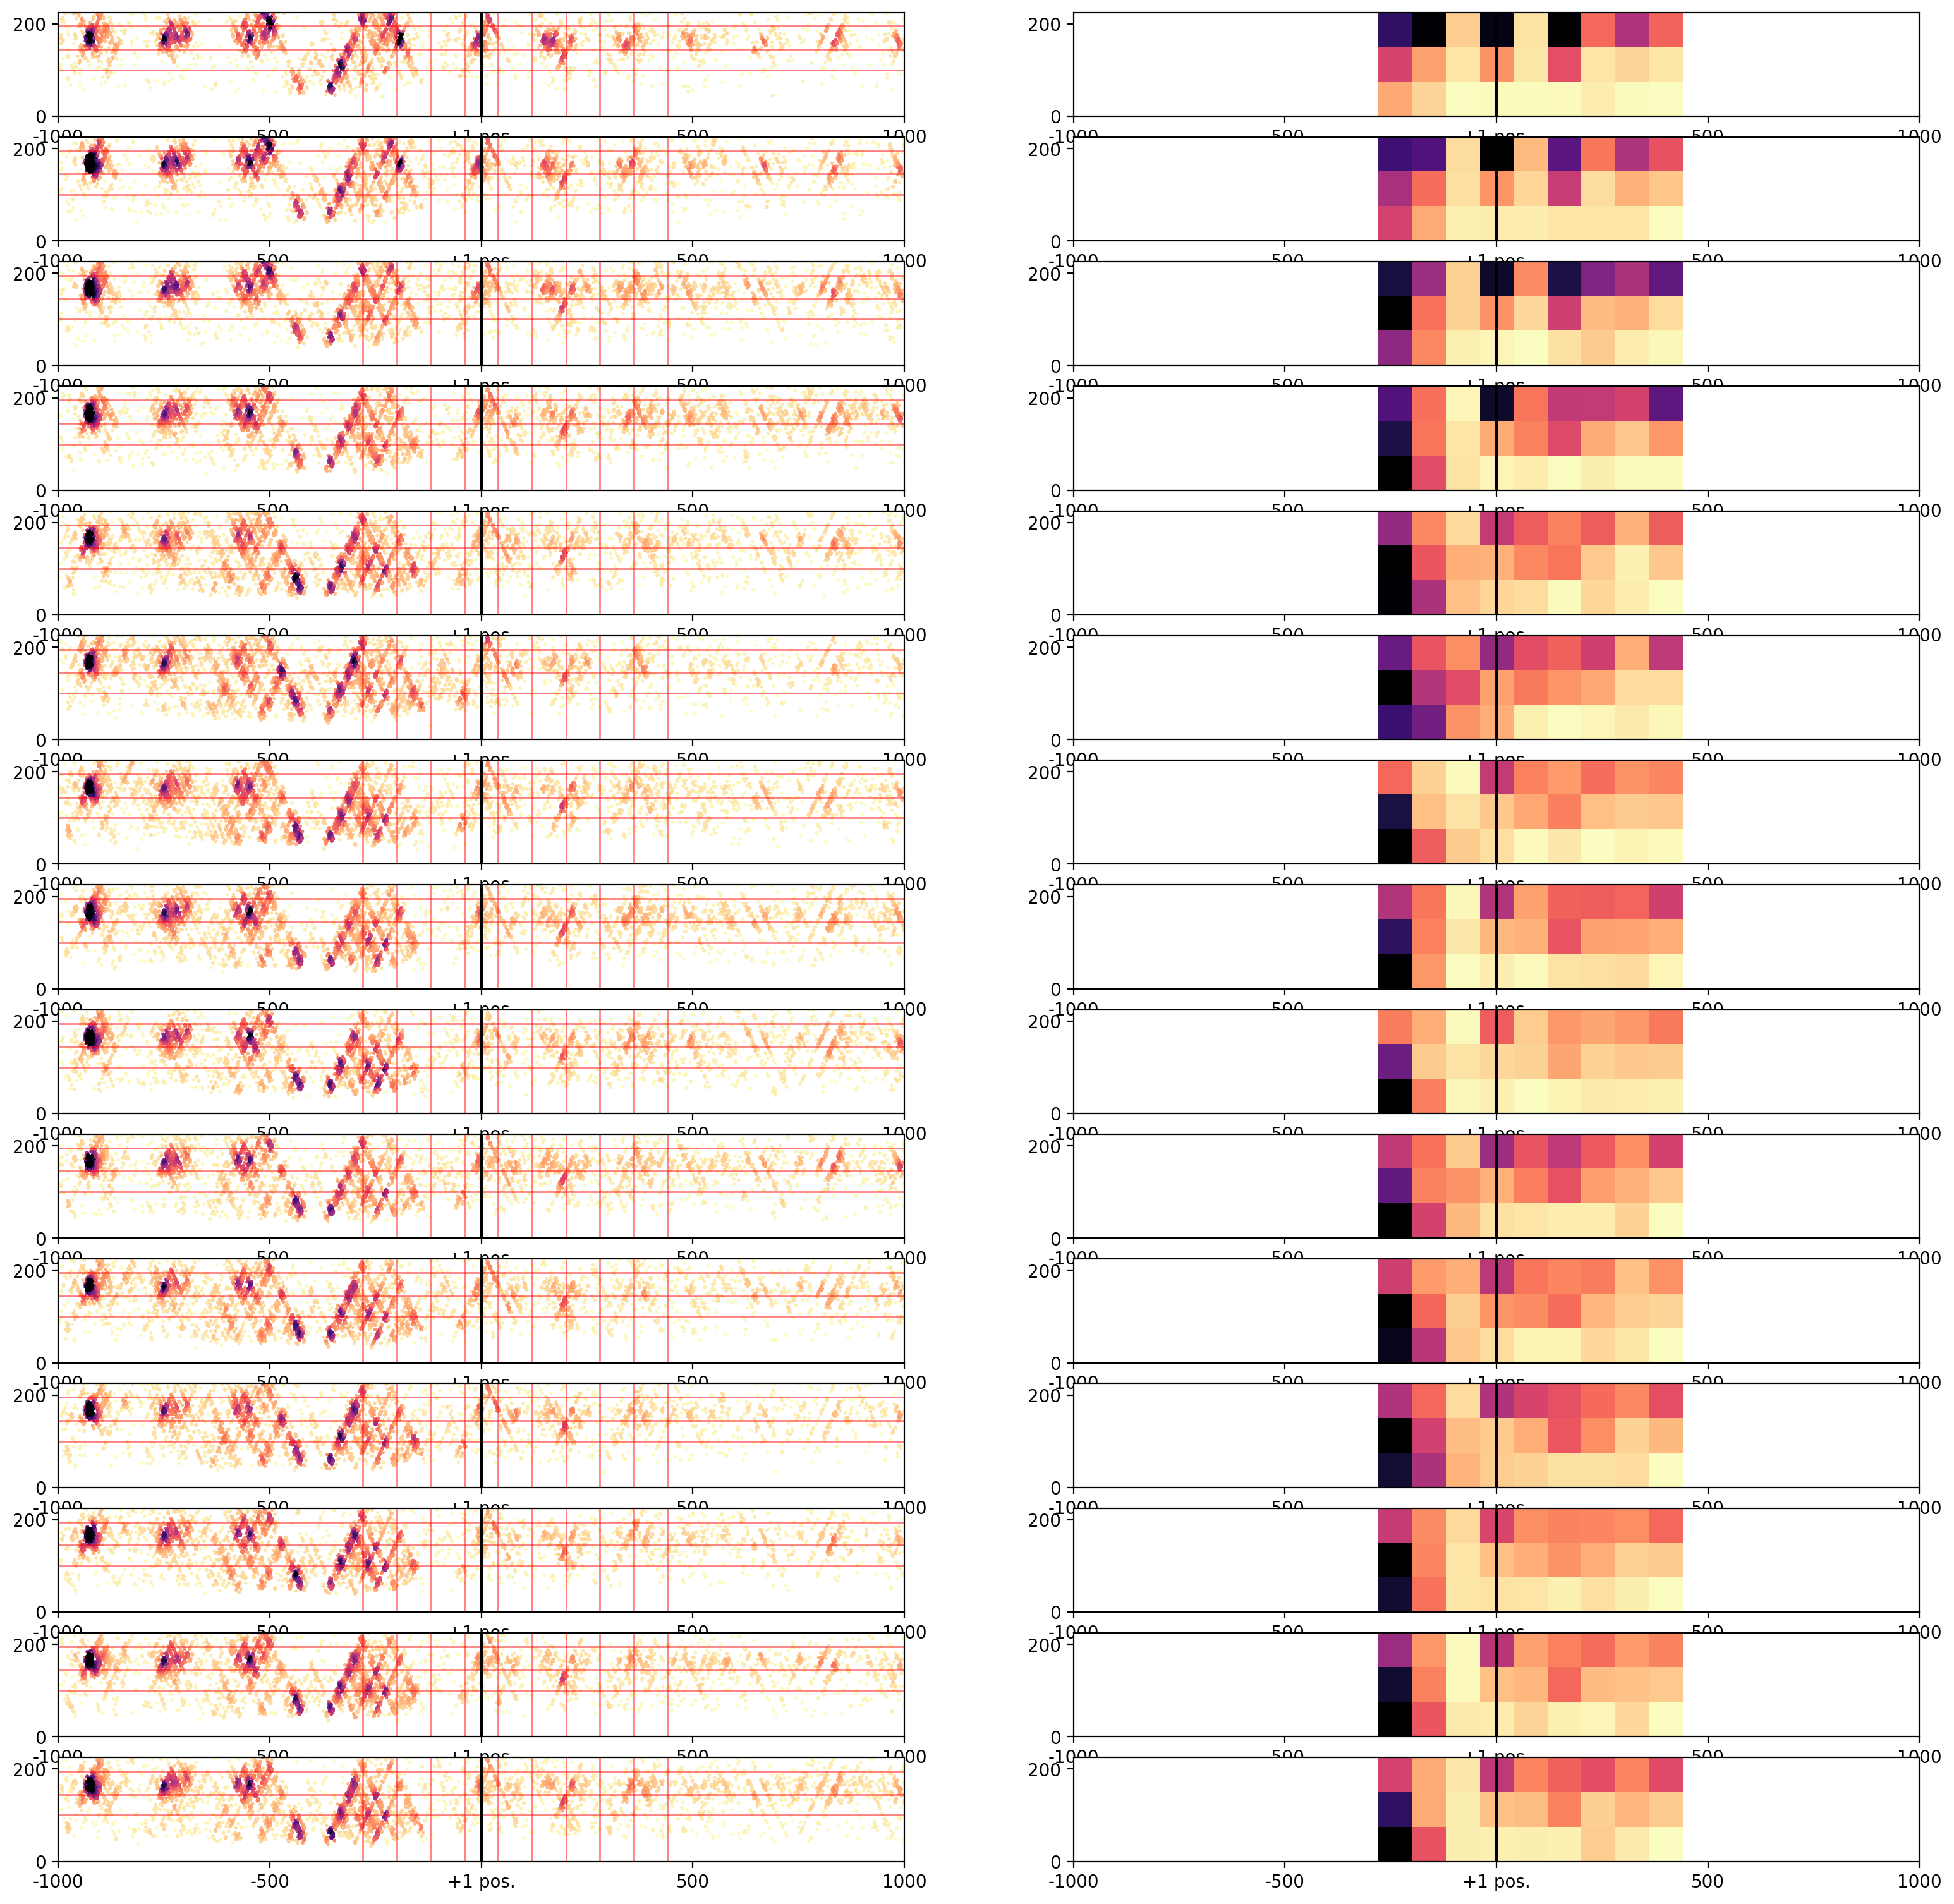

In [125]:
chromatin_gridder.plot_raw_and_grid()

In [127]:
# Testing Crick gene:

chromatin_gridder.set_gene('CLN2')
plus_one = chromatin_gridder.find_max_plusOne_pos()
print(f"Computed the plus one location as: {plus_one}")
chromatin_gridder.create_bins_per_all_sample()

Computed the plus one location as: 66785
The histogram shape around the TSS is: (3, 9)


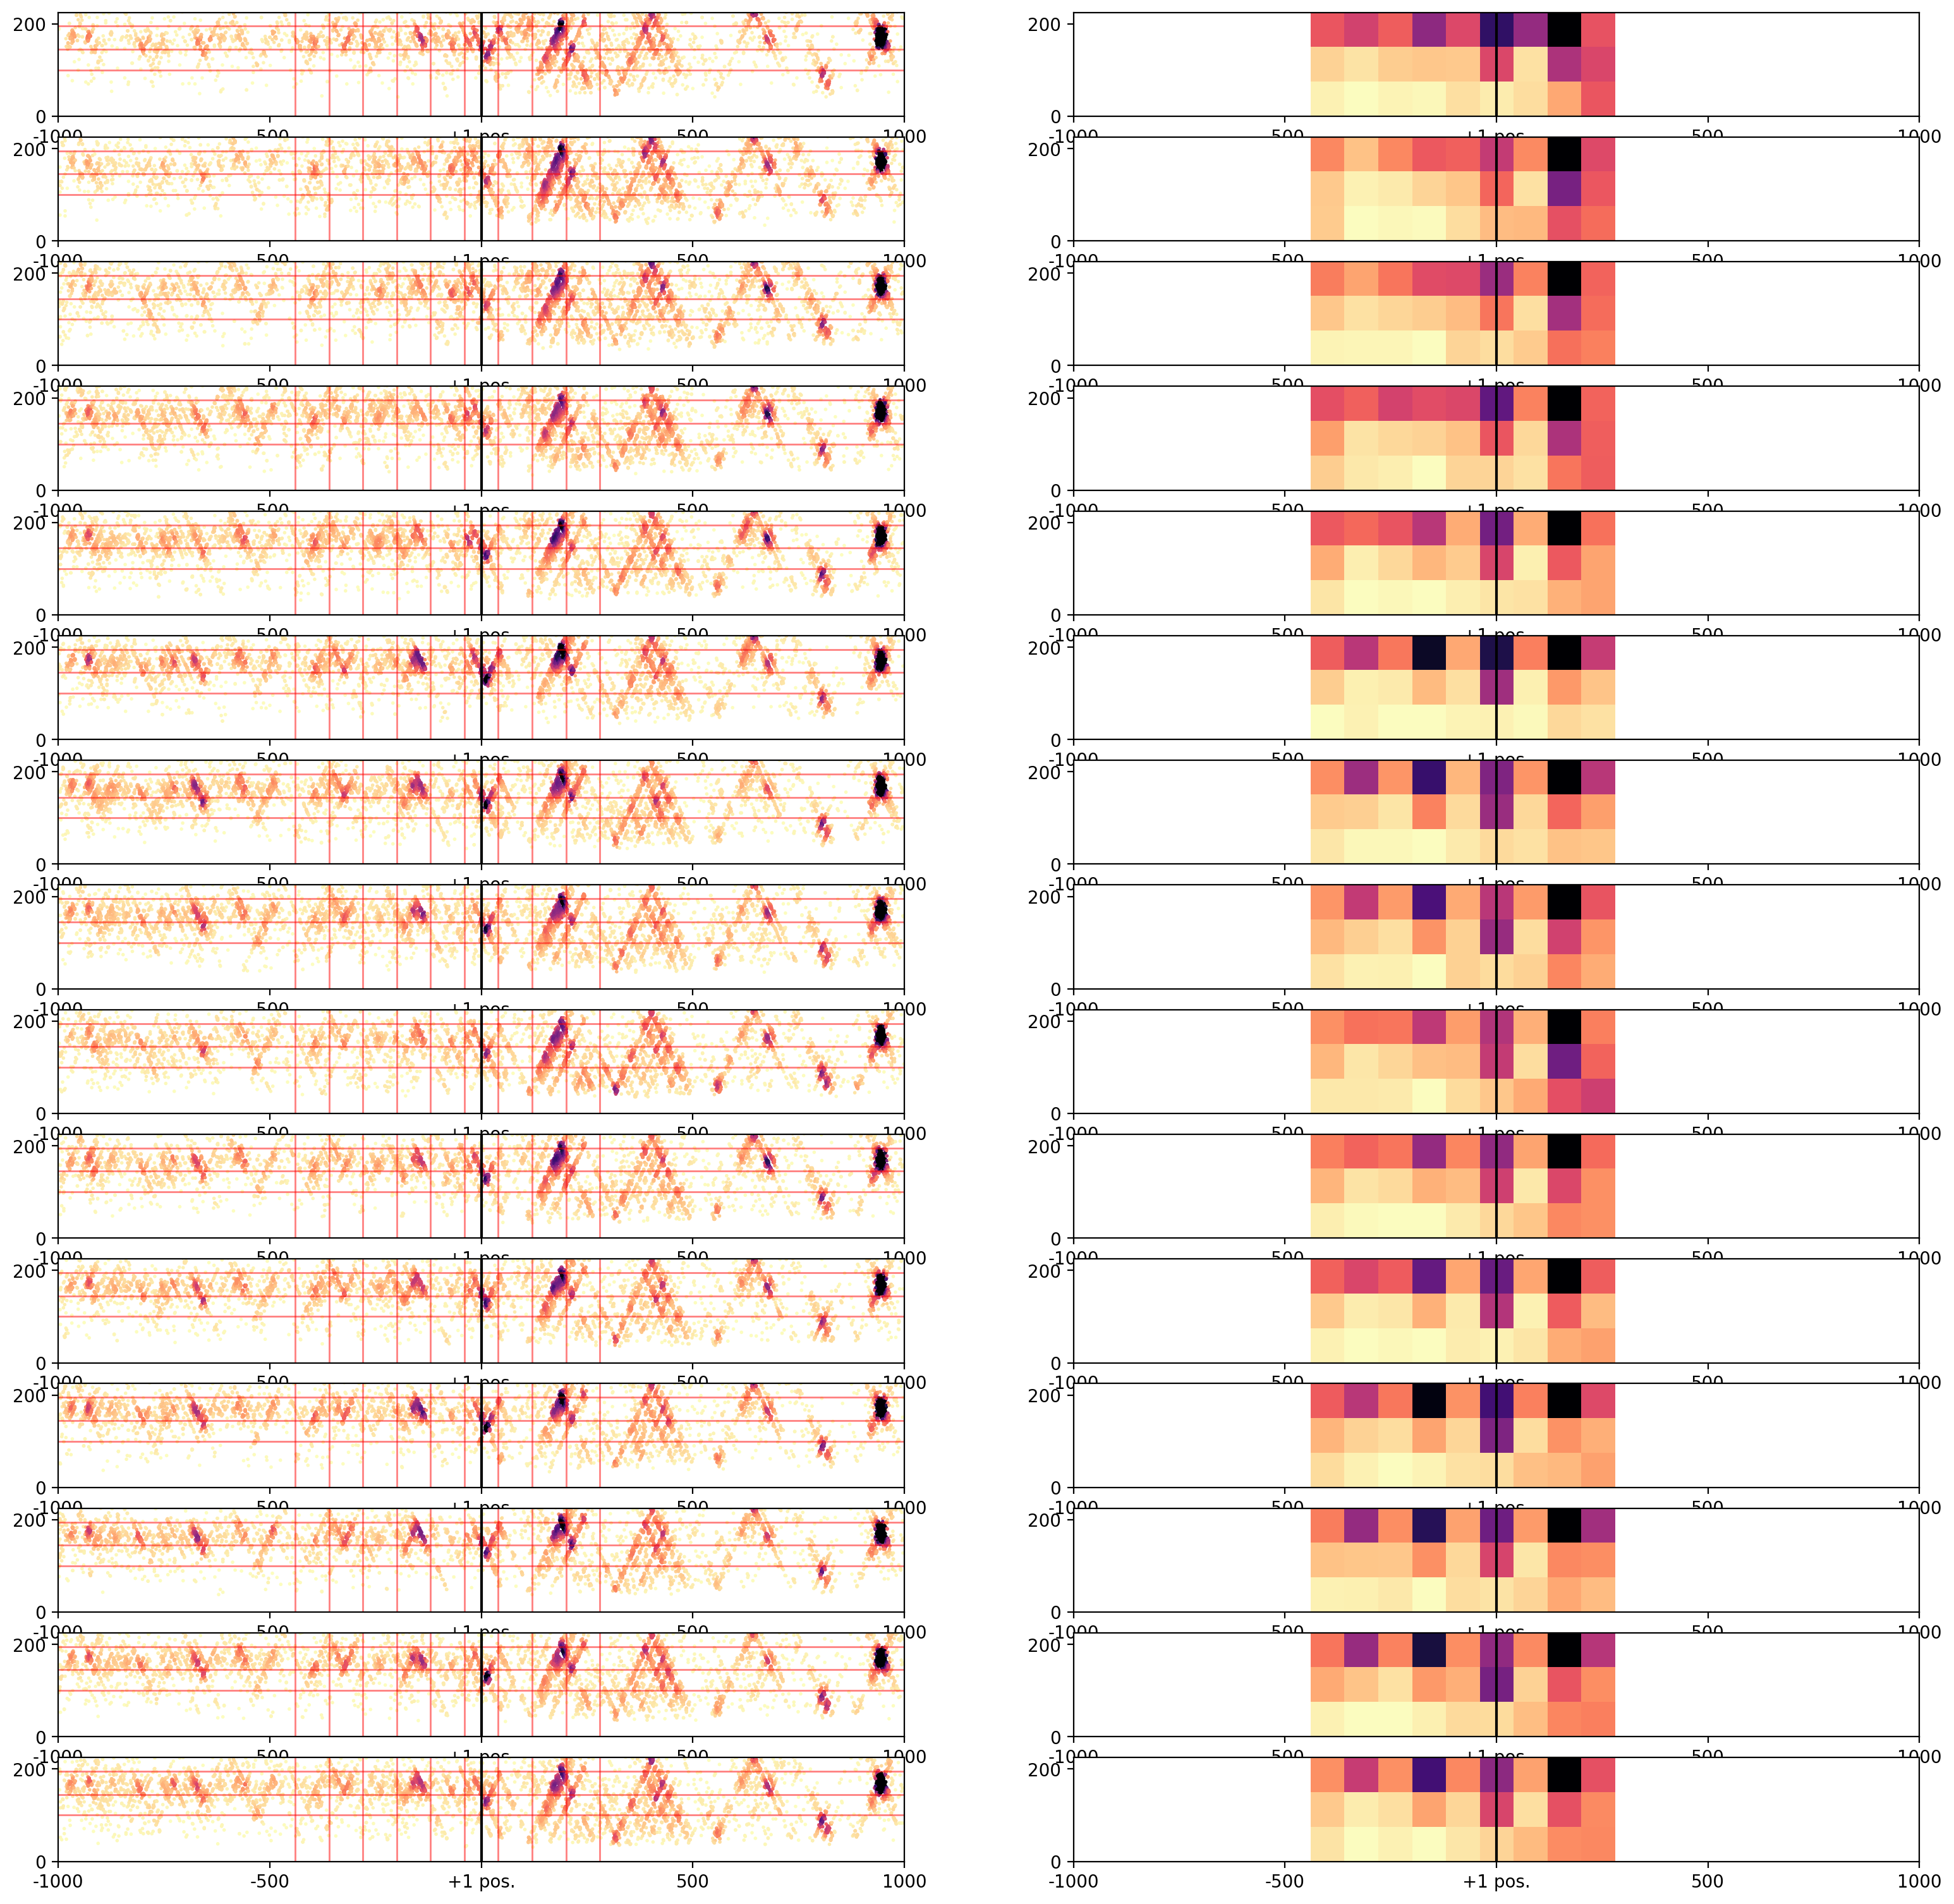

In [128]:
chromatin_gridder.plot_raw_and_grid()

# We will need to remember to flip these genes for the deconvolution (or maybe not?)

# It shouldn't actually make a difference, because we are flattening them anyway.
